In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/UBQ/ubqCR/'

1.3 ± 0.0 $\AA$


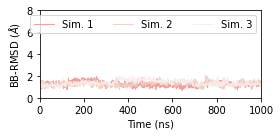

In [2]:

ymax = 8

nsims=3

plt.figure(figsize = (4,2))

colors = ['#F49595','#F1CEBE','#F8EDEB']

vals = []

for i in range(1,nsims+1):
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(i),skiprows=18)[::50]
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds
    
    vals.append(np.mean(rmsd)) # mean 

    plt.plot(time,rmsd,color = colors[i-1],alpha=0.9,linewidth = 1,label = 'Sim. {}'.format(i))
    
plt.legend(ncol=3)
print('{:.1f} ± {:.1f} $\\AA$'.format(np.mean(vals),np.std(vals)/np.sqrt(nsims)))
plt.ylim(0,ymax)
plt.xlim(0,np.max(time))

    
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')

plt.tight_layout()
plt.savefig('BB_RMSD.pdf')

